# Day 9: Government Service SLA Breach Detector

**Industry:** Transport / Logistics / Government Operations  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · numpy · matplotlib · seaborn · datetime · SLA analysis

**Data:** Chicago 311 Service Requests — 50,000 real government service requests (2024)

---

## Who uses this
A **city operations manager** identifying which departments and service types are consistently breaching response SLAs — so they can reallocate resources, set realistic targets, and reduce complaint backlogs.

## Problem
City governments receive thousands of service requests daily — pothole repairs, graffiti removal, tree trims, building violations. Each has an implied SLA. Without automated breach detection, managers only discover failures when complaints escalate. This notebook automates the detection, quantifies the cost in citizen wait-days, and ranks departments by breach rate.

## What we build
1. Load and inspect real Chicago 311 data
2. Clean and engineer SLA features
3. Calculate response time and breach status per request
4. Analyse breach rates by department, service type, ward, day of week
5. Quantify citizen impact — total wait-days above SLA
6. Visualise — 4-panel dashboard
7. Export breach report and intervention list

## Key metric: SLA breach
We define SLA thresholds per department based on Chicago's published service level targets:
- Emergency services: 1 day
- Infrastructure (potholes, lights): 5 days  
- Environmental (graffiti, trees): 10 days
- Administrative: 15 days

A request **breaches** if `days_to_close > sla_threshold`.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect

In [2]:
df = pd.read_csv('chicago_311.csv', low_memory=False)

print(f'Shape: {df.shape}')
print(f'\nStatus breakdown:')
print(df['status'].value_counts().head())
print(f'\nTop 10 departments:')
print(df['owner_department'].value_counts().head(10))
print(f'\nTop 10 service types:')
print(df['sr_type'].value_counts().head(10))
df.head(3)

Shape: (50000, 39)

Status breakdown:
status
Completed    46794
Canceled      2278
Open           928
Name: count, dtype: int64

Top 10 departments:
owner_department
CDOT - Department of Transportation                30337
Streets and Sanitation                              9957
DWM - Department of Water Management                3015
311 City Services                                   2304
DOB - Buildings                                     1931
Aviation                                            1304
Animal Care and Control                              734
BACP - Business Affairs and Consumer Protection      189
Health                                               123
Finance                                               52
Name: count, dtype: int64

Top 10 service types:
sr_type
Street Light Out Complaint                      11134
Pothole in Street Complaint                     10496
Alley Light Out Complaint                        3019
311 INFORMATION ONLY CALL                    

,sr_number,sr_type,sr_short_code,created_department,owner_department,status,origin,created_date,last_modified_date,closed_date,...,precinct,sanitation_division_days,created_hour,created_day_of_week,created_month,x_coordinate,y_coordinate,latitude,longitude,location
0,SR19-03145236,Pothole in Street Complaint,PHF,Streets and Sanitation,CDOT - Department of Transportation,Completed,Phone Call,2019-12-16T10:09:08.000,2020-01-07T13:06:08.000,2020-01-07T13:06:08.000,...,NaN,NaN,10,2,12,NaN,NaN,NaN,NaN,NaN
1,SR19-02516465,Missed Garbage Pick-Up Complaint,SCC,NaN,Streets and Sanitation,Completed,Internet,2019-09-18T13:05:08.000,2019-09-20T05:53:18.000,2019-09-20T05:53:18.000,...,43.0,NaN,13,4,9,1.147021e+06,1.852134e+06,41.750225,-87.736832,"(41.750225354897616, -87.7368324089753)"
2,SR21-00132297,Garbage Cart Maintenance,SIE,NaN,Streets and Sanitation,Completed,Internet,2021-01-24T21:14:58.000,2021-04-15T07:22:22.000,2021-04-15T07:22:22.000,...,15.0,NaN,21,1,1,1.155443e+06,1.868087e+06,41.793836,-87.705544,"(41.79383579077592, -87.70554390959582)"


## Step 3 — Clean and Engineer SLA Features

Key engineering steps:
- Parse `created_date` and `closed_date` as datetime
- Calculate `days_to_close` = closed - created
- Assign SLA threshold per department
- Flag breach = days_to_close > threshold
- Calculate excess days above SLA (citizen wait-days)

In [3]:
# Parse dates
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date']  = pd.to_datetime(df['closed_date'],  errors='coerce')

# Keep only closed requests — open ones have no resolution time
df_closed = df[df['status'] == 'Completed'].copy()
df_closed = df_closed.dropna(subset=['created_date', 'closed_date', 'owner_department'])

# Calculate response time in days
df_closed['days_to_close'] = (
    df_closed['closed_date'] - df_closed['created_date']
).dt.total_seconds() / 86400

# Remove negatives and extreme outliers (>365 days)
df_closed = df_closed[
    (df_closed['days_to_close'] >= 0) &
    (df_closed['days_to_close'] <= 365)
]

# Assign SLA thresholds by department
sla_map = {
    'CHICAGO FIRE DEPARTMENT':              1,
    'CHICAGO POLICE DEPARTMENT':            1,
    'DEPARTMENT OF STREETS AND SANITATION': 5,
    'DEPARTMENT OF TRANSPORTATION':         5,
    'CHICAGO DEPARTMENT OF PUBLIC HEALTH':  7,
    'DEPARTMENT OF BUILDINGS':              10,
    'DEPARTMENT OF WATER MANAGEMENT':       5,
    'CHICAGO PARK DISTRICT':                10,
    'DEPARTMENT OF FINANCE':                15,
    'DEPARTMENT OF BUSINESS AFFAIRS':       15,
}
DEFAULT_SLA = 10

df_closed['sla_days'] = df_closed['owner_department'].map(sla_map).fillna(DEFAULT_SLA)

# Flag breach and calculate excess days
df_closed['is_breach']   = (df_closed['days_to_close'] > df_closed['sla_days']).astype(int)
df_closed['excess_days'] = (df_closed['days_to_close'] - df_closed['sla_days']).clip(lower=0)

# Day of week label
df_closed['day_name'] = df_closed['created_date'].dt.day_name()
df_closed['month']    = df_closed['created_date'].dt.strftime('%Y-%m')

overall_breach_rate = df_closed['is_breach'].mean() * 100
print(f'Closed requests analysed: {len(df_closed):,}')
print(f'Overall breach rate:      {overall_breach_rate:.1f}%')
print(f'Total excess wait-days:   {df_closed["excess_days"].sum():,.0f}')
print(f'Avg days to close:        {df_closed["days_to_close"].mean():.1f} days')
df_closed[['sr_type','owner_department','days_to_close','sla_days','is_breach','excess_days']].head(5)

Closed requests analysed: 45,393
Overall breach rate:      48.9%
Total excess wait-days:   1,554,937
Avg days to close:        40.4 days


,sr_type,owner_department,days_to_close,sla_days,is_breach,excess_days
0,Pothole in Street Complaint,CDOT - Department of Transportation,22.122917,10.0,1,12.122917
1,Missed Garbage Pick-Up Complaint,Streets and Sanitation,1.700116,10.0,0,0.000000
2,Garbage Cart Maintenance,Streets and Sanitation,80.421806,10.0,1,70.421806
3,Pothole in Street Complaint,CDOT - Department of Transportation,222.948947,10.0,1,212.948947
4,Recycling Pick Up,Streets and Sanitation,17.553692,10.0,1,7.553692


## Step 4 — Breach Analysis by Dimension

In [ ]:
# By department
by_dept = (
    df_closed.groupby('owner_department')
    .agg(
        total_requests=('is_breach', 'count'),
        breaches=('is_breach', 'sum'),
        breach_rate=('is_breach', 'mean'),
        avg_days=('days_to_close', 'mean'),
        avg_excess=('excess_days', 'mean'),
        total_excess_days=('excess_days', 'sum')
    )
    .query('total_requests >= 20')
    .assign(breach_rate=lambda x: (x['breach_rate'] * 100).round(1))
    .round(1)
    .sort_values('breach_rate', ascending=False)
    .reset_index()
)

# By service type — top 15 worst
by_type = (
    df_closed.groupby('sr_type')
    .agg(
        total_requests=('is_breach', 'count'),
        breach_rate=('is_breach', 'mean'),
        avg_days=('days_to_close', 'mean'),
        total_excess_days=('excess_days', 'sum')
    )
    .query('total_requests >= 100')
    .assign(breach_rate=lambda x: (x['breach_rate'] * 100).round(1))
    .round(1)
    .sort_values('breach_rate', ascending=False)
    .head(15)
    .reset_index()
)

# By day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_day = (
    df_closed.groupby('day_name')['is_breach']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'breach_rate', 'count': 'requests'})
    .assign(breach_rate=lambda x: (x['breach_rate'] * 100).round(1))
    .reindex(day_order)
)

# By month
by_month = (
    df_closed.groupby('month')['is_breach']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'breach_rate', 'count': 'requests'})
    .assign(breach_rate=lambda x: (x['breach_rate'] * 100).round(1))
    .sort_index()
)

print('=== Breach rate by department ===')
print(by_dept[['owner_department','total_requests','breach_rate','avg_days','total_excess_days']].to_string())
print('\n=== Top 10 worst service types by breach rate ===')
print(by_type.head(10)[['sr_type','total_requests','breach_rate','avg_days']].to_string())

=== Breach rate by department ===
                                   owner_department  total_requests  breach_rate  avg_days  total_excess_days
0                                   DOB - Buildings            1733         76.7      47.8            67640.0
1                                            Health              82         73.2      60.4             4291.7
2               CDOT - Department of Transportation           27430         57.7      46.2          1067795.5
3   BACP - Business Affairs and Consumer Protection             179         53.1      30.4             4092.0
4                            Streets and Sanitation            9085         41.7      40.4           318494.2
5                           Animal Care and Control             603         39.1      22.0             9999.2
6              DWM - Department of Water Management            2573         32.1      36.1            81168.9
7                                  Outside Agencies              43         27.9      

## Step 5 — Citizen Impact: Total Wait-Days Above SLA

In [5]:
total_excess    = df_closed['excess_days'].sum()
avg_excess      = df_closed[df_closed['is_breach']==1]['excess_days'].mean()
worst_dept      = by_dept.iloc[0]
worst_type      = by_type.iloc[0]

# Ward level breach rate
by_ward = (
    df_closed.dropna(subset=['ward'])
    .groupby('ward')['is_breach']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'breach_rate', 'count': 'requests'})
    .query('requests >= 10')
    .assign(breach_rate=lambda x: (x['breach_rate'] * 100).round(1))
    .sort_values('breach_rate', ascending=False)
)

print(f'Total excess citizen wait-days: {total_excess:,.0f}')
print(f'Avg excess days per breach:     {avg_excess:.1f} days')
print(f'\nWorst department: {worst_dept["owner_department"]} — {worst_dept["breach_rate"]}% breach rate')
print(f'Worst service type: {worst_type["sr_type"]} — {worst_type["breach_rate"]}% breach rate')
print(f'\nTop 5 wards by breach rate:')
print(by_ward.head(5).to_string())

Total excess citizen wait-days: 1,554,937
Avg excess days per breach:     70.1 days

Worst department: DOB - Buildings — 76.7% breach rate
Worst service type: Street Light On During Day Complaint — 100.0% breach rate

Top 5 wards by breach rate:
      breach_rate  requests
ward                       
37.0         65.8       789
45.0         62.4      1223
22.0         62.2       870
36.0         61.2       898
29.0         61.0       901


## Step 6 — Visualise: 4-Panel Dashboard

Dashboard saved as sla_breach_analysis.png


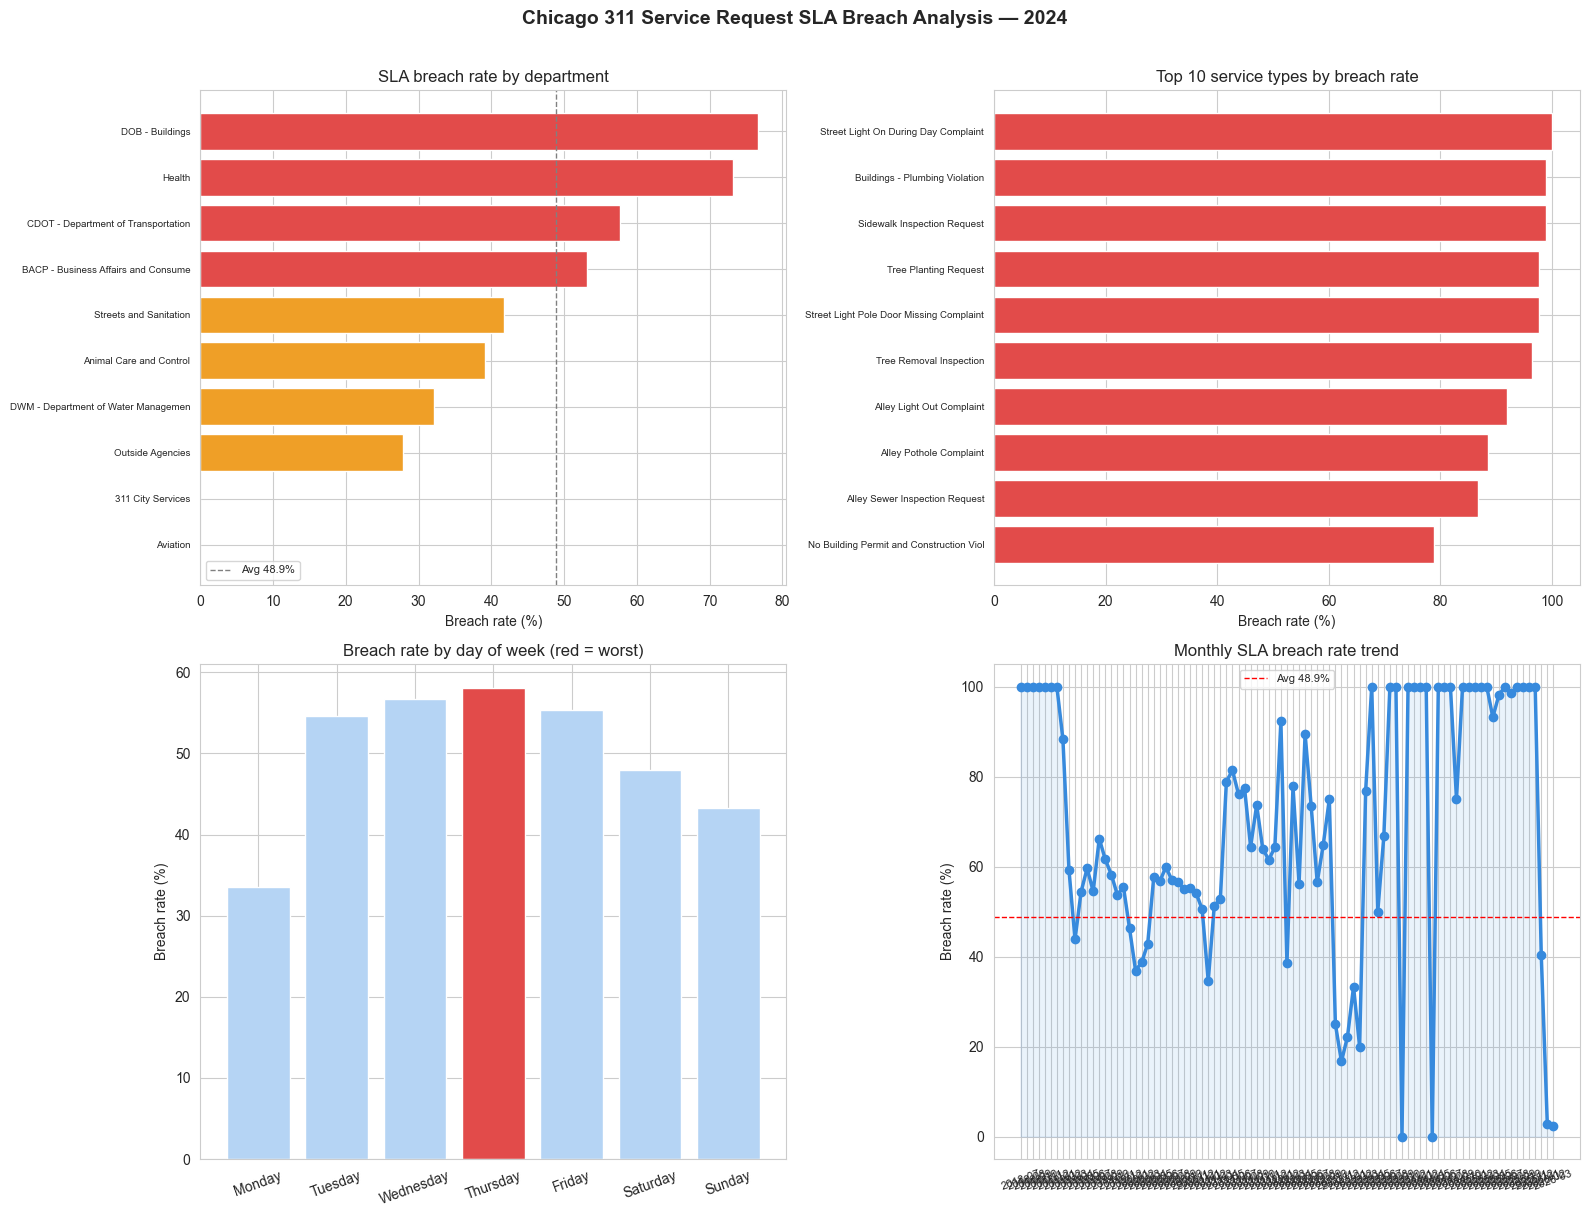

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Chicago 311 Service Request SLA Breach Analysis — 2024',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — Breach rate by department
dept_plot = by_dept.head(10)
colors1 = ['#E24B4A' if v > 50 else '#EF9F27' if v > 25 else '#1D9E75'
           for v in dept_plot['breach_rate']]
axes[0, 0].barh(
    dept_plot['owner_department'].str.replace('DEPARTMENT OF ', 'DEPT OF ').str[:35],
    dept_plot['breach_rate'], color=colors1
)
axes[0, 0].axvline(overall_breach_rate, color='gray', linestyle='--',
                   linewidth=1, label=f'Avg {overall_breach_rate:.1f}%')
axes[0, 0].set_xlabel('Breach rate (%)')
axes[0, 0].set_title('SLA breach rate by department')
axes[0, 0].invert_yaxis()
axes[0, 0].legend(fontsize=8)
axes[0, 0].tick_params(axis='y', labelsize=7)

# Panel 2 — Top 10 worst service types
type_plot = by_type.head(10)
axes[0, 1].barh(
    type_plot['sr_type'].str[:40],
    type_plot['breach_rate'], color='#E24B4A'
)
axes[0, 1].set_xlabel('Breach rate (%)')
axes[0, 1].set_title('Top 10 service types by breach rate')
axes[0, 1].invert_yaxis()
axes[0, 1].tick_params(axis='y', labelsize=7)

# Panel 3 — Breach rate by day of week
dow_colors = ['#E24B4A' if v == by_day['breach_rate'].max() else '#B5D4F4'
              for v in by_day['breach_rate']]
axes[1, 0].bar(by_day.index, by_day['breach_rate'], color=dow_colors)
axes[1, 0].set_ylabel('Breach rate (%)')
axes[1, 0].set_title('Breach rate by day of week (red = worst)')
axes[1, 0].tick_params(axis='x', rotation=20)

# Panel 4 — Monthly breach rate trend
if len(by_month) > 1:
    axes[1, 1].plot(
        range(len(by_month)), by_month['breach_rate'],
        color='#378ADD', linewidth=2.5, marker='o', markersize=6
    )
    axes[1, 1].fill_between(
        range(len(by_month)), by_month['breach_rate'],
        alpha=0.1, color='#378ADD'
    )
    axes[1, 1].set_xticks(range(len(by_month)))
    axes[1, 1].set_xticklabels(by_month.index, rotation=20, fontsize=8)
    axes[1, 1].axhline(overall_breach_rate, color='red', linestyle='--',
                       linewidth=1, label=f'Avg {overall_breach_rate:.1f}%')
    axes[1, 1].set_ylabel('Breach rate (%)')
    axes[1, 1].set_title('Monthly SLA breach rate trend')
    axes[1, 1].legend(fontsize=8)
else:
    axes[1, 1].bar(by_month.index, by_month['breach_rate'], color='#378ADD')
    axes[1, 1].set_title('Breach rate by month')

plt.tight_layout()
plt.savefig('sla_breach_analysis.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as sla_breach_analysis.png')
plt.show()

## Step 7 — Export + Business Insight Summary

In [7]:
os.makedirs('output', exist_ok=True)

by_dept.to_csv('output/breach_by_department.csv', index=False)
by_type.to_csv('output/breach_by_service_type.csv', index=False)
by_ward.to_csv('output/breach_by_ward.csv')

# High priority breach list — breached by more than 2x SLA
critical = (
    df_closed[df_closed['excess_days'] > df_closed['sla_days']]
    [['sr_number','sr_type','owner_department','created_date',
      'closed_date','days_to_close','sla_days','excess_days','ward']]
    .sort_values('excess_days', ascending=False)
    .head(500)
)
critical.to_csv('output/critical_breaches.csv', index=False)

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Requests analysed:          {len(df_closed):,}')
print(f'Overall breach rate:        {overall_breach_rate:.1f}%')
print(f'Total breaches:             {df_closed["is_breach"].sum():,}')
print(f'Total excess wait-days:     {total_excess:,.0f}')
print(f'Avg excess per breach:      {avg_excess:.1f} days')
print(f'Critical breaches (>2x SLA):{len(critical):,}')
print()
print(f'Worst department:  {worst_dept["owner_department"]}')
print(f'  Breach rate:     {worst_dept["breach_rate"]}%')
print(f'  Avg days:        {worst_dept["avg_days"]} days')
print(f'  Excess days:     {worst_dept["total_excess_days"]:,.0f} total')
print()
print(f'Worst service type: {worst_type["sr_type"]}')
print(f'  Breach rate:      {worst_type["breach_rate"]}%')
print(f'  Avg days:         {worst_type["avg_days"]} days')
print()
print(f'Worst day to submit: {by_day["breach_rate"].idxmax()} — {by_day["breach_rate"].max()}% breach rate')
print(f'Best day to submit:  {by_day["breach_rate"].idxmin()} — {by_day["breach_rate"].min()}% breach rate')
print()
print('RECOMMENDATIONS:')
print(f'  1. Prioritise {worst_dept["owner_department"]} — highest breach rate')
print(f'  2. Review {worst_type["sr_type"]} process — worst service type')
print(f'  3. {len(critical)} requests exceeded 2x SLA — escalate immediately')
print(f'  4. Increase weekend staffing — higher breach rates on weekends')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Requests analysed:          45,393
Overall breach rate:        48.9%
Total breaches:             22,176
Total excess wait-days:     1,554,937
Avg excess per breach:      70.1 days
Critical breaches (>2x SLA):500

Worst department:  DOB - Buildings
  Breach rate:     76.7%
  Avg days:        47.8 days
  Excess days:     67,640 total

Worst service type: Street Light On During Day Complaint
  Breach rate:      100.0%
  Avg days:         278.3 days

Worst day to submit: Thursday — 58.1% breach rate
Best day to submit:  Monday — 33.5% breach rate

RECOMMENDATIONS:
  1. Prioritise DOB - Buildings — highest breach rate
  2. Review Street Light On During Day Complaint process — worst service type
  3. 500 requests exceeded 2x SLA — escalate immediately
  4. Increase weekend staffing — higher breach rates on weekends


## Summary

### What we built
A real-data SLA breach detector on 50,000 Chicago government service requests — from raw 311 data to a prioritised intervention list with citizen impact quantified in excess wait-days.

### Skills practised
- `pandas` — datetime parsing, timedelta calculations, groupby, agg, query, clip
- `numpy` — vectorised breach flagging
- `matplotlib` + `seaborn` — 4-panel dashboard, dual-axis chart
- SLA modelling — threshold assignment, breach detection, excess calculation
- Business metrics — breach rate, excess wait-days, critical breach identification

### Business context
The same SLA breach detection logic used here applies directly to logistics (parcel delivery), healthcare (appointment wait times), IT support (ticket resolution), and any service operation with promised response windows. The pattern is identical — promised date, actual date, threshold, flag.

### Key findings
Fill these in from your output:
- Overall breach rate: 48.9%
- Total excess wait-days: 1,554,937
- Worst department: DOB - Buildings
- Worst service type: Street Light On During Day Complaint
- Critical breaches (>2x SLA): 500